pip install matplotlib
pip install seaborn

In [ ]:
import matplotlib as plt1
print(plt1.__version__)

3.10.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print(sns.__version__)

0.13.2


In [ ]:
pip show matplotlib

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [ ]:
# load the data
tips = sns.load_dataset("tips")

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
tips.info() # provide information about columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
# shape of the dataframe
tips.shape

(244, 7)

In [ ]:
# datatypes of the columns
tips.dtypes

,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


In [ ]:
# check missing values
tips.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


Tips dataset comprises of 244 rows with 7 columns. None of the rows are empty throughout all the features. All the data types are correctly mapped to each column

In [ ]:
# descriptive statistics

tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Total bill is unsymmetrical data. It shows the pattern of positive skewness that means there are people who have contributed to more in the bill of the party. Mean > Median.

Tips - Mean and Median are kind of same in value. There is huge spread between Q3 and maximum value which shows variation

Size - We are only able to see the values which are ordinal in nature starts with 1 ends with 6.

Univariate analysis

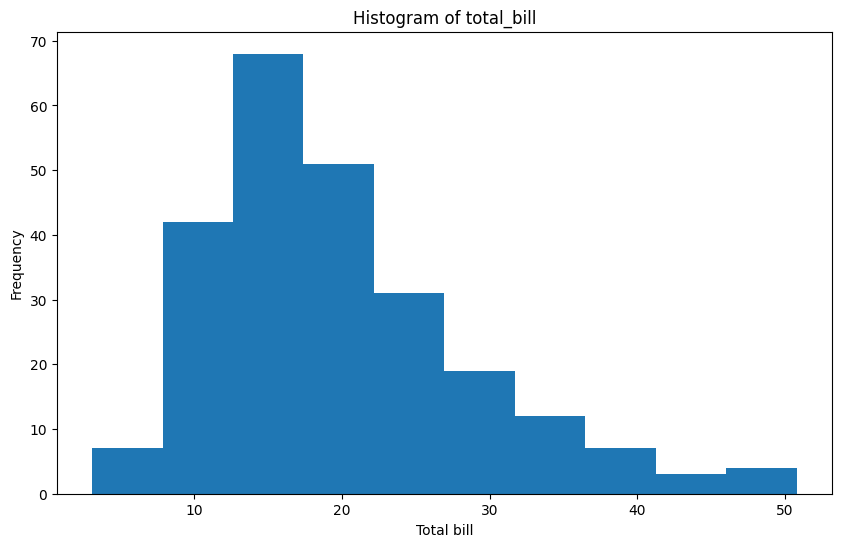

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(tips['total_bill'])
plt.title('Histogram of total_bill')
plt.xlabel('Total bill')
plt.ylabel('Frequency')
plt.show()

In [ ]:
help(plt.hist)

Help on function hist in module matplotlib.pyplot:

hist(x: 'ArrayLike | Sequence[ArrayLike]', bins: 'int | Sequence[float] | str | None' = None, *, range: 'tuple[float, float] | None' = None, density: 'bool' = False, weights: 'ArrayLike | None' = None, cumulative: 'bool | float' = False, bottom: 'ArrayLike | float | None' = None, histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar', align: "Literal['left', 'mid', 'right']" = 'mid', orientation: "Literal['vertical', 'horizontal']" = 'vertical', rwidth: 'float | None' = None, log: 'bool' = False, color: 'ColorType | Sequence[ColorType] | None' = None, label: 'str | Sequence[str] | None' = None, stacked: 'bool' = False, data=None, **kwargs) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'
    Compute and plot a histogram.

    This method uses `numpy.histogram` to bin the data in *x* and count the
    number of values in each bin, then draws the distribution ei

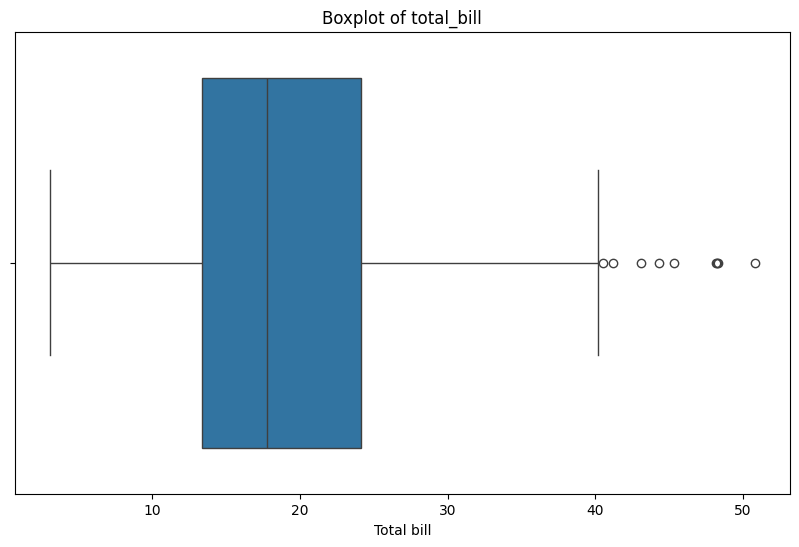

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x=tips['total_bill'])
plt.title('Boxplot of total_bill')
plt.xlabel('Total bill')
plt.show()

Certain bills which are more than 40 $

In [ ]:
tips[tips['total_bill'] > 40]['size'].value_counts()

,count
size,
4,4
3,3
5,1
6,1
2,1


/tmp/ipython-input-2440518773.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(tips['total_bill'], shade=True)


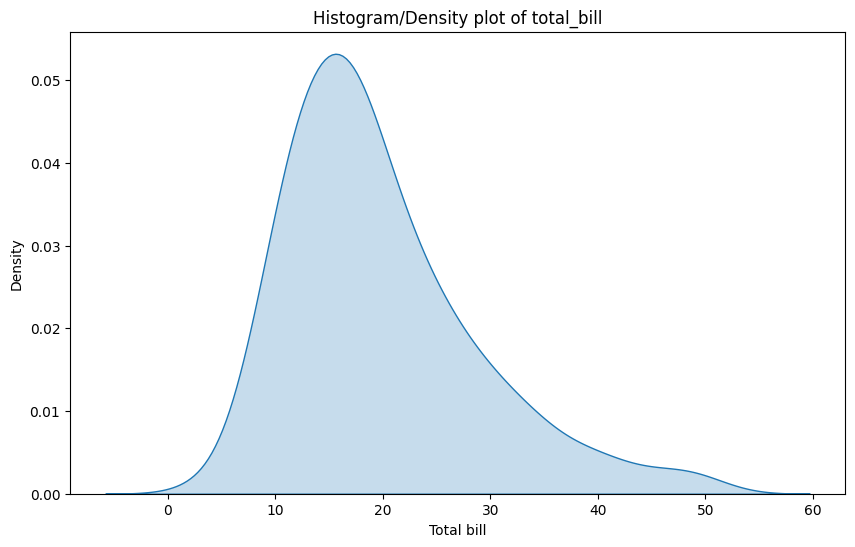

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(tips['total_bill'], shade=True)
plt.title('Histogram/Density plot of total_bill')
plt.xlabel('Total bill')
plt.show()

In [ ]:
tips[tips['total_bill'] > 50]

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.0,Male,Yes,Sat,Dinner,3


In [ ]:
tips.dtypes

,0
total_bill,float64
tip,float64
sex,category
smoker,category
day,category
time,category
size,int64


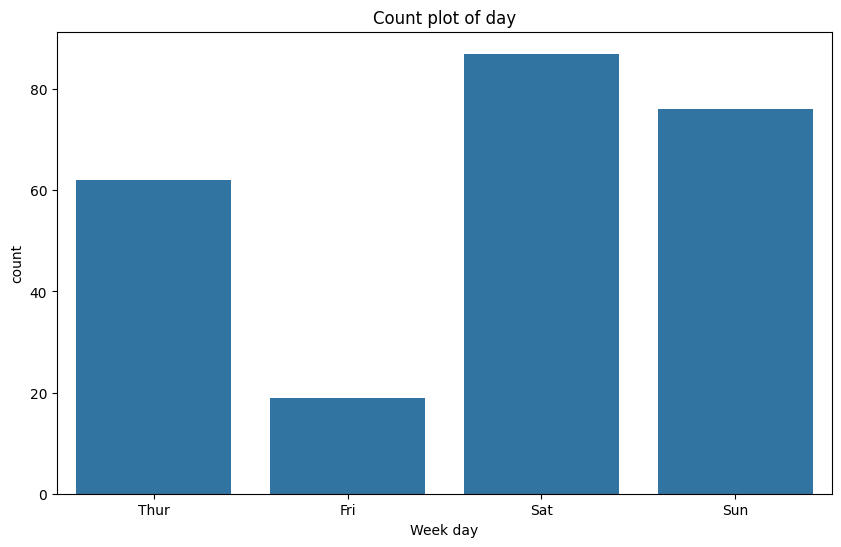

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x=tips['day'])
plt.title('Count plot of day')
plt.xlabel('Week day')
plt.show()

People prefer going to restaurant in weekends rather than weekdays. They prefer their team dinner or lunch during thursday not on friday

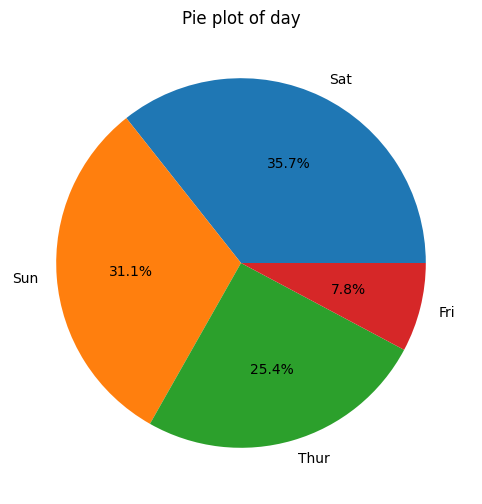

In [ ]:
plt.figure(figsize=(10,6))
tips['day'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Pie plot of day')
plt.ylabel('')
# plt.xlabel('Week day')
plt.show()

Bivariate analysis

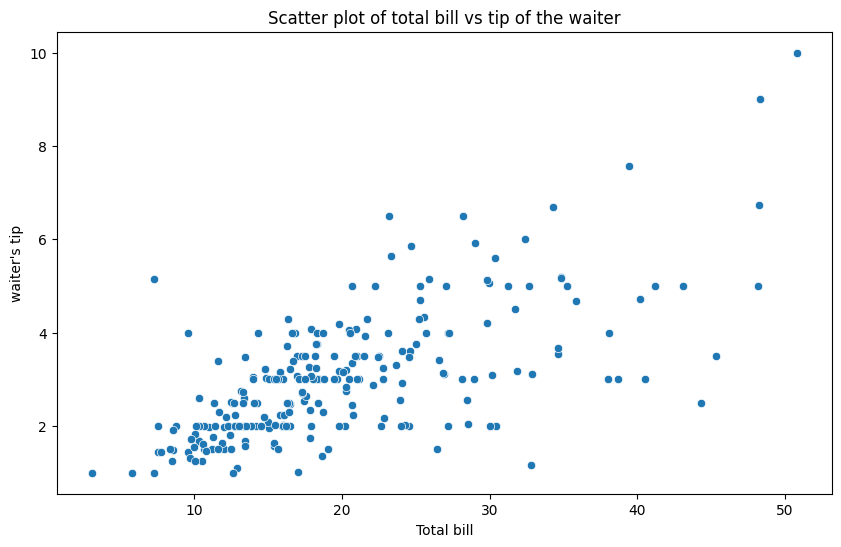

In [ ]:
# scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(x=tips['total_bill'], y=tips['tip'], data=tips)
plt.title('Scatter plot of total bill vs tip of the waiter')
plt.ylabel("waiter's tip")
plt.xlabel('Total bill')
plt.show()

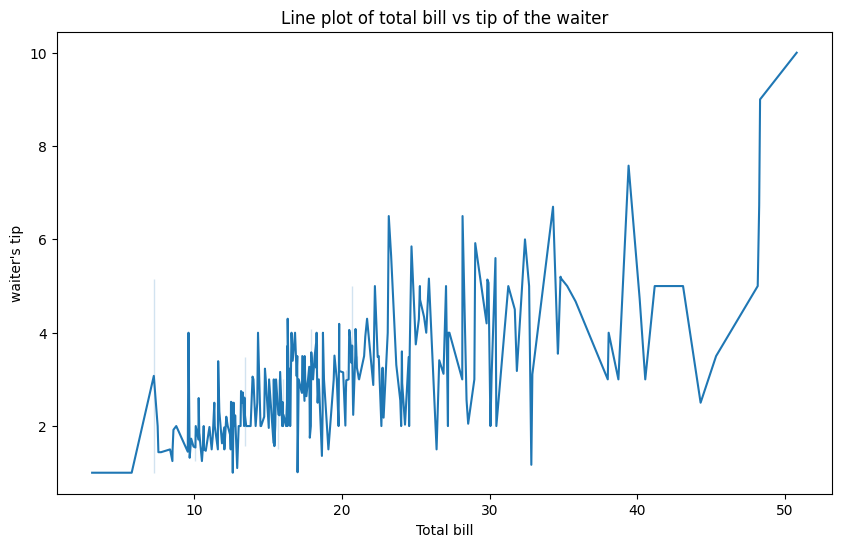

In [ ]:
# lineplot - only use it in context of timing but as timing is already category
plt.figure(figsize=(10,6))
sns.lineplot(x=tips['total_bill'], y=tips['tip'], data=tips)
plt.title('Line plot of total bill vs tip of the waiter')
plt.ylabel("waiter's tip")
plt.xlabel('Total bill')
plt.show()

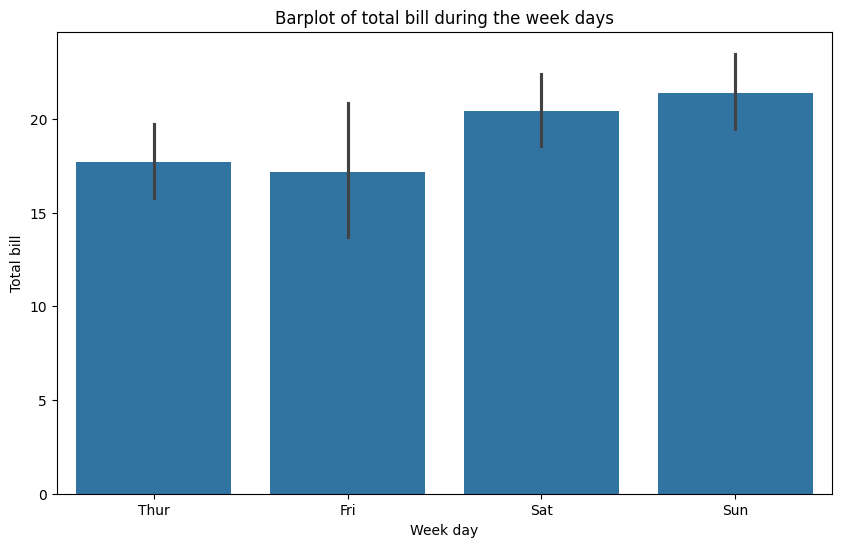

In [ ]:
# lineplot - only use it in context of timing but as timing is already category
plt.figure(figsize=(10,6))
sns.barplot(x='day', y='total_bill', data=tips)
plt.title('Barplot of total bill during the week days')
plt.ylabel("Total bill")
plt.xlabel('Week day')
plt.show()

Black wedges talks aobut 95% confidence interval over the mean of total bill. They show uncertainty or variation around the bar height

CI width depends on standard error
SE = stddev/sqrt of n

As n increases, SE decreases, CI narrow down
-> Black wedges gets smaller

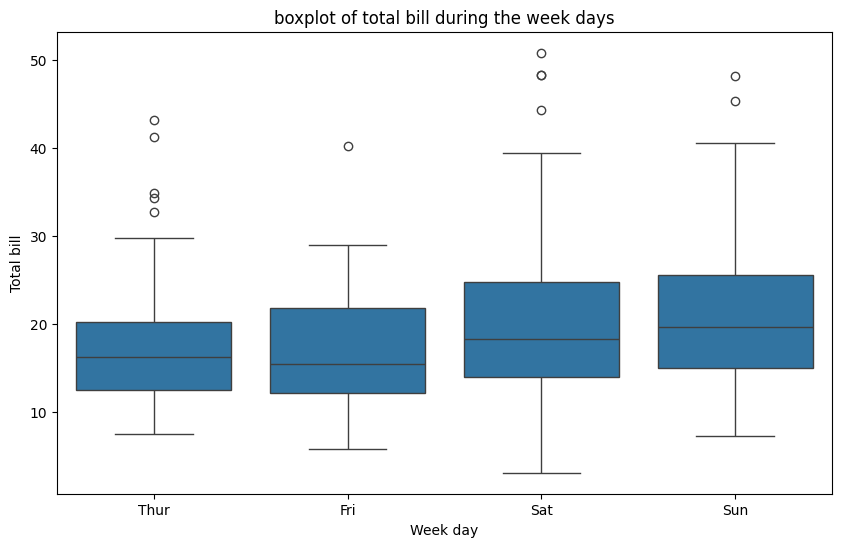

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='day', y='total_bill', data=tips)
plt.title('boxplot of total bill during the week days')
plt.ylabel("Total bill")
plt.xlabel('Week day')
plt.show()

Multivariate analysis

In [ ]:
numeric_cols = tips.select_dtypes(include=['int64', 'float64']).columns

tips[numeric_cols].corr()

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


total bill increases with increase on tip and size

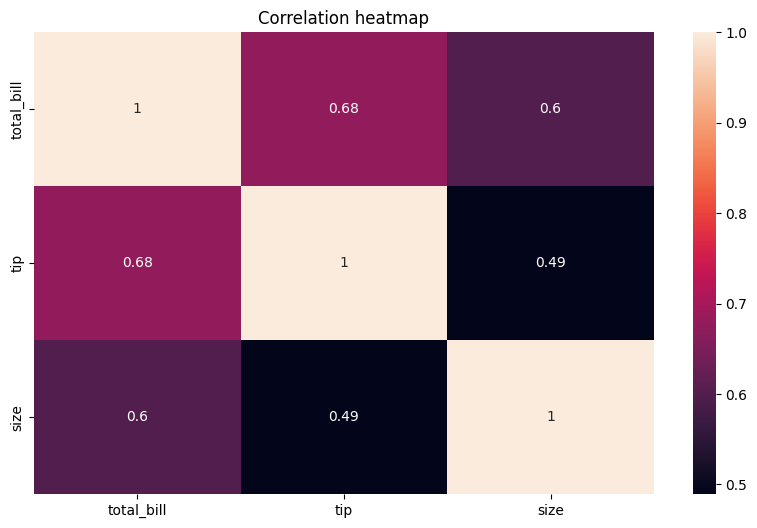

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(tips[numeric_cols].corr(), annot=True)
plt.title('Correlation heatmap')
plt.show()

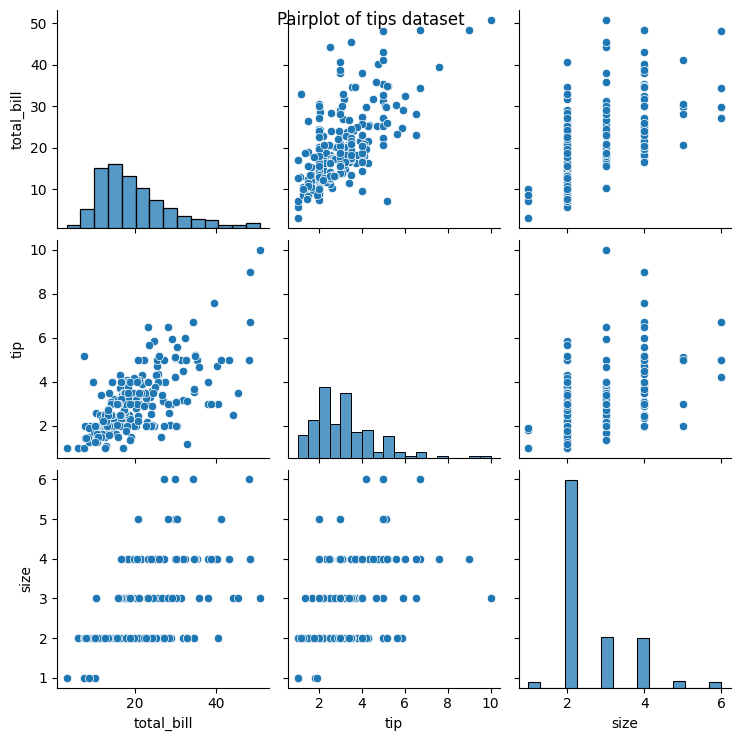

In [ ]:
#pairplot
sns.pairplot(tips[numeric_cols])
plt.suptitle('Pairplot of tips dataset')
plt.show()